In [1]:
import numpy as np
from relativistic import relativistics, Deltap_p
from commonformulas import beam_rigidity, _2pi, get_units
from scipy.constants import c, e, electron_volt
import sympy as sy
def _a_(*args):
    return np.array(args)

from scipy.special import jv

import pandas as pd


unit_dicts = get_units()

for unit_dict in unit_dicts:
    for key,value in unit_dict.items():
        globals()[key] = value




In [25]:
def omega_critical(gamma, rho):
    return 3/2 * c / rho * gamma**3

def theta_critical(omega, omega_c, gamma):
    return 1/gamma * (omega_c/omega)**(1/3)

def theta_critical_Jackson(omega, omega_c, gamma):
    return np.sqrt((2*omega_c/omega + 1)**(2/3) - 1)/gamma


# def Cgamma_calc(E0):
#     return 1/(epsilon_0_e_eVm * E0**4)

def radiated_power(gamma, rho, q = 1):
    beta = np.sqrt(1-1/gamma**2)
    return q**2 * c * gamma**4/ (6*np.pi * epsilon_0_e_eVm * rho**2) * beta**2
    
def tau_y_calc(Enom, U0, T0, jy = 1):
    return 2/jy * Enom/U0 * T0

def tau_x_calc(Enom, U0, T0, jx):
    return 2/jx * Enom/U0 * T0

def tau_z_calc(Enom, U0, T0, jz):
    return 2/jz * Enom/U0 * T0


def jy_calc():
    return 1

def jx_calc(I2, I4):
    return 1 - I4/I2

def jz_calc(I2, I4):
    return 2 + I4/I2


def epsilon_x_eq_calc(Cq, gamma, jx, I5, I2):
    return Cq * gamma**2 / jx * I5/I2

def N_particles_beam(I_beam, T0, q=1):
    return I_beam * T0 / e




class Ngamma_undulator:

    def __call__(self, K, n, N, Ib):
        Y = self.Y(K, n)
        Fn = self.Fn(K, n, Y)
        Qn = self.Qn(K, n, Fn)

        return 1.43e14*N * Ib * Qn
        
    def Y(self, K, n):
        return (n*K**2)/(4*(1+K**2/2))
    
    def Fn(self, K, n, Y):
        return (n**2 * K**2)/(1+K**2/2)**2 * (jv((n+1)/2, Y) - jv((n-1)/2, Y))**2

    def Qn(self, K, n, Fn):
        return (1+K**2/2)/n * Fn





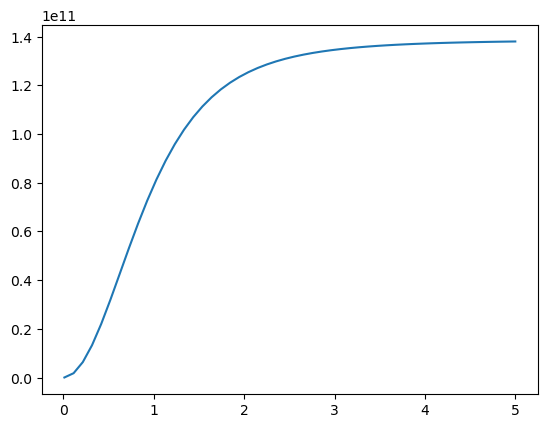

In [27]:
n  =1

N = 1

Ibeam = 1*mA

ngamma = Ngamma_undulator()

Ks = np.linspace(0.01, 5)

ngammas = ngamma(Ks, n, N, Ibeam)


import matplotlib.pyplot as plt

plt.plot(Ks, ngammas)

### Ex2

In [14]:
E_rest = 511*keV



By = 50e-6 #T

V_acc = 25 *kV

E_kin = V_acc * eV/V



particles = relativistics(E_rest).given_Ekin(E_kin)


print("p", particles["p"]/keV, "keV/c")

rho = beam_rigidity().rho(particles["p"], By)

print("rho", rho, "m")

Pgamma = radiated_power(particles["gamma"], rho)

print(f"Pgamma {Pgamma:.4e} eV/s")



p 161.78689687363436 keV/c
rho 10.793259974114116 m
Pgamma 2.7246e-04 eV/s


In [15]:
E_rest = 938*MeV

p = particles["p"]

By = 50e-6 #T

V_acc = 25 *kV

E_kin = V_acc * eV/V



particles = relativistics(E_rest).given_p(p)
print(particles["p"]/MeV)

print("p", particles["p"]/MeV, "MeV/c")

rho = beam_rigidity().rho(particles["p"], By)

print("rho", rho, "m")

Pgamma = radiated_power(particles["gamma"], rho)

print(f"Pgamma {Pgamma:.4e} eV/s")



0.16178689687363437
p 0.16178689687363437 MeV/c
rho 10.793259974114116 m
Pgamma 7.3495e-11 eV/s


### Ex

In [32]:
E = 300*GeV

E_rest = 511*keV

B = 30*1e-9 #T

p = E

rho = beam_rigidity().rho(p, B)

print(f"rho{rho:.3e}")

gamma = E/E_rest

omega_c = omega_critical(gamma, rho)

E_c = hbar_eVs * omega_c

print("critical energy", E_c/eV, "eV")

rho3.336e+10
critical energy 1.7955582388230211 eV


In [ ]:
protons = {
    "name":"p",
    "C0":6336,
    "Ekin":820*GeV,
    "By":4.6818,
    "I_beam":160*mA
}

protons = {
    "name":"e",
    "C0":6336,
    "Ekin":27.5*GeV,
    "By":0.1503,
    "I_beam":58*mA
}

### Ex3

In [22]:
E_new_E_old = 110/100

epsilon_new_epsioln_old = E_new_E_old**2

(1-1/(110/100)**2)*100

17.355371900826455